# 3 · Volltext → Kandidatenindex → LLM-gestützte Disambiguierung

Dieses Notebook zeigt einen vollständigen, aber bewusst überschaubaren Workflow für
vorhandenen OCR-/HTR-Volltext:

**Volltext → GLiNER → Personenfundstellen → Namensvarianten → Kandidatencluster → Visualisierung → lokales LLM → Prüfdatensatz**

Die einzelnen Schritte beantworten unterschiedliche Fragen:

1. **GLiNER:** Wo werden Personen erwähnt?
2. **Normalisierung + Phonetik:** Welche Namensformen könnten zusammengehören?
3. **Kandidatencluster:** Welche Fundstellen sollten gemeinsam geprüft werden?
4. **Lokales LLM:** Welche Fundstellen sprechen aufgrund ihres Kontexts wahrscheinlich für dieselbe Person?
5. **Archivfachliche Prüfung:** Welche Identitäten werden tatsächlich zusammengeführt oder getrennt?

> **Disambiguierung ist Inhalt, keine Fußnote.**


## Ablauf

1. Volltext laden
2. GLiNER-Modell und Entitätstypen definieren
3. langen Text in überlappenden Fenstern vollständig verarbeiten
4. Fundstellen und Kontexte sichern
5. Namen normalisieren und phonetisch vergleichen
6. großzügige Kandidatencluster bilden
7. Clusterkarten und Fundstellenverteilung visualisieren
8. problematische Cluster mit `gpt-oss:20b` quellengebunden bewerten
9. LLM-Antwort deterministisch validieren
10. vorgeschlagene Untergruppen visualisieren
11. Basis- und LLM-Prüfdatensatz als CSV exportieren


## Installation

Im **gleichen Jupyter-Kernel**:

```python
%pip install -U \
    "gliner>=0.2.27" \
    "transformers>=4.57.3,<5" \
    sentencepiece protobuf \
    pandas rapidfuzz matplotlib openai
```

Danach den Kernel gegebenenfalls einmal neu starten.

Das Notebook setzt **keinen festen Hugging-Face-Cachepfad**. Auf einem JupyterHub
wird der normale benutzerspezifische Cache verwendet.

Für den LLM-Schritt wird ein persönlicher API-Key benötigt. Entweder vorher setzen:

```bash
export TELOTA_AI_API_KEY="..."
```

oder später im Notebook interaktiv eingeben.


In [1]:
%pip install -U \
    "gliner>=0.2.27" \
    "transformers>=4.57.3,<5" \
    sentencepiece protobuf \
    pandas rapidfuzz matplotlib openai

Note: you may need to restart the kernel to use updated packages.


In [2]:
from pathlib import Path
import json
import re
import unicodedata
from itertools import combinations

import pandas as pd
from IPython.display import display, Markdown
from rapidfuzz.fuzz import ratio

TEXT_PATH = Path("data/03_volltext/volltext.txt")
OUTPUT_DIR = Path("output")
OUTPUT_DIR.mkdir(exist_ok=True)

CSV_PATH = OUTPUT_DIR / "03_kandidatenindex.csv"

MODEL_ID = "urchade/gliner_multi-v2.1"
NER_THRESHOLD = 0.40

# Zahl der GLiNER-Splitter-Tokens, die sich zwei benachbarte Fenster teilen.
OVERLAP_TOKENS = 64

MATCH_HIGH = 90
MATCH_REVIEW = 75

if not TEXT_PATH.exists():
    raise FileNotFoundError(f"Volltext nicht gefunden: {TEXT_PATH}")

text = TEXT_PATH.read_text(encoding="utf-8")

print(f"Zeichen: {len(text):,}")
print(f"Quelle:  {TEXT_PATH}")


Zeichen: 16,378
Quelle:  data/03_volltext/volltext.txt


## 1. GLiNER laden und Labels definieren

GLiNER bekommt die gewünschten Kategorien direkt beim Aufruf.

Für den Kandidatenindex interessieren uns vor allem Personen. Orte, Organisationen,
Datierungen und Werke werden ebenfalls erkannt, weil sie für spätere
Disambiguierung über den Kontext hilfreich sein können.


In [3]:
from gliner import GLiNER

model = GLiNER.from_pretrained(MODEL_ID)

labels = {
    "person": "Name einer konkreten Person",
    "location": "Ort oder geografischer Name",
    "organization": "Institution, Behörde oder Organisation",
    "date": "Datum oder Zeitangabe",
    "werk": "Publikation, direkt oder indirekt referenzierter Text oder Buch",
}

print("max_len:", model.config.max_len)
print("words_splitter_type:", model.config.words_splitter_type)
print("max_width:", getattr(model.config, "max_width", None))


/opt/conda/lib/python3.13/site-packages/torch/jit/_script.py:1491: FutureWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(
/opt/conda/lib/python3.13/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

/opt/conda/lib/python3.13/site-packages/transformers/convert_slow_tokenizer.py:566: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(


max_len: 384
words_splitter_type: whitespace
max_width: 12


## 2. Langen Volltext vollständig verarbeiten

`predict_entities()` teilt lange Dokumente **nicht automatisch** auf. Text oberhalb
von `model.config.max_len` würde sonst am Ende abgeschnitten.

Deshalb zerlegen wir den Text anhand der **GLiNER-eigenen Token-/Zeichen-Maps** in
überlappende Fenster. Dadurch:

- wird der gesamte Volltext verarbeitet,
- werden Entitäten an Fenstergrenzen nicht so leicht zerschnitten,
- lassen sich die lokalen Zeichenpositionen wieder auf den Gesamttext zurückrechnen.

Treffer aus den Überlappungen werden anschließend nach
`(start, end, label)` dedupliziert; bei identischen Treffern bleibt der höchste Score.


In [4]:
def iter_gliner_windows(model, text: str, labels, overlap: int):
    prepared = model.prepare_batch(text, labels)

    if not prepared["tokens"]:
        return

    tokens = prepared["tokens"][0]
    starts = prepared["start_token_map"][0]
    ends = prepared["end_token_map"][0]

    window_size = int(model.config.max_len)

    if not 0 <= overlap < window_size:
        raise ValueError(
            f"overlap muss zwischen 0 und {window_size - 1} liegen."
        )

    step = window_size - overlap

    for first in range(0, len(tokens), step):
        last = min(first + window_size, len(tokens))

        char_start = int(starts[first])
        char_end = int(ends[last - 1])

        yield {
            "first_token": first,
            "last_token": last,
            "char_start": char_start,
            "char_end": char_end,
            "text": text[char_start:char_end],
        }

        if last == len(tokens):
            break


prepared = model.prepare_batch(text, labels)
token_count = len(prepared["tokens"][0]) if prepared["tokens"] else 0

required_overlap = max(0, int(getattr(model.config, "max_width", 1)) - 1)
overlap = max(OVERLAP_TOKENS, required_overlap)
overlap = min(overlap, int(model.config.max_len) - 1)

windows = list(iter_gliner_windows(model, text, labels, overlap))

print(f"GLiNER-Tokens im Dokument: {token_count:,}")
print(f"Modelllimit pro Fenster:   {model.config.max_len}")
print(f"Overlap:                   {overlap} Tokens")
print(f"Fenster:                   {len(windows)}")


GLiNER-Tokens im Dokument: 2,718
Modelllimit pro Fenster:   384
Overlap:                   64 Tokens
Fenster:                   9


## 3. Named Entity Recognition über alle Fenster

Jedes Fenster wird separat verarbeitet. Die von GLiNER gelieferten Zeichenpositionen
sind zunächst relativ zum Fenster und werden hier wieder in **Dokumentkoordinaten**
umgerechnet.


In [5]:
all_entities = []

for window_no, window in enumerate(windows, start=1):
    chunk_entities = model.predict_entities(
        window["text"],
        labels,
        threshold=NER_THRESHOLD,
    )

    for entity in chunk_entities:
        entity = entity.copy()

        entity["start"] = int(entity["start"]) + window["char_start"]
        entity["end"] = int(entity["end"]) + window["char_start"]
        entity["window"] = window_no

        all_entities.append(entity)

    print(
        f"Fenster {window_no:>3}/{len(windows)}: "
        f"{len(chunk_entities):>3} Treffer"
    )


# Exakte Überlappungs-Dubletten zusammenführen.
best = {}

for entity in all_entities:
    key = (
        int(entity["start"]),
        int(entity["end"]),
        str(entity["label"]).lower(),
    )

    if key not in best or float(entity["score"]) > float(best[key]["score"]):
        best[key] = entity

entities = sorted(
    best.values(),
    key=lambda e: (int(e["start"]), int(e["end"]), str(e["label"])),
)

print()
print(f"Treffer vor Deduplizierung: {len(all_entities):,}")
print(f"Treffer danach:             {len(entities):,}")


Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


Fenster   1/9:  13 Treffer
Fenster   2/9:  22 Treffer
Fenster   3/9:  19 Treffer
Fenster   4/9:  19 Treffer
Fenster   5/9:  17 Treffer
Fenster   6/9:  21 Treffer
Fenster   7/9:  22 Treffer
Fenster   8/9:  22 Treffer
Fenster   9/9:   5 Treffer

Treffer vor Deduplizierung: 160
Treffer danach:             141


In [6]:
ENTITY_COLUMNS = [
    "start", "end", "text", "label", "score", "window"
]

if entities:
    entities_df = (
        pd.DataFrame(entities)
        .sort_values(["start", "end", "label"])
        .reset_index(drop=True)
    )
else:
    entities_df = pd.DataFrame(columns=ENTITY_COLUMNS)
    display(Markdown(
        f"**Keine Entitäten mit threshold={NER_THRESHOLD} gefunden.**"
    ))

display(entities_df.head(50))


,start,end,text,label,score,window
0,38,116,"Städtischen Kommission für Armenpflege,\nSchul...",organization,0.644990,1
1,278,356,"Städtischen Kommission für\nArmenpflege, Schul...",organization,0.734246,1
2,649,670,Carl Friedrich Becker,person,0.551378,1
3,685,699,Bernhard Meyer,person,0.423696,1
4,705,729,Apotheker Gustav Lehmann,person,0.400347,1
5,742,765,Johann Friedrich Müller,person,0.681915,1
6,823,836,Clara Wegener,person,0.642818,1
7,873,906,Magistratssekretär Theodor Krüger,person,0.425878,1
8,1020,1035,Frau Anna Becke,person,0.429503,1
9,1057,1069,August\nBecke,person,0.468755,1


## 4. Kontext an jeder Fundstelle sichern

Ein Name allein reicht zur Identifikation nicht.

Deshalb behalten wir für jede Fundstelle einen Ausschnitt aus dem **ursprünglichen
Gesamttext**, nicht nur aus dem jeweiligen GLiNER-Fenster.


In [7]:
def context_window(text: str, start: int, end: int, radius: int = 120) -> str:
    left = max(0, start - radius)
    right = min(len(text), end + radius)

    snippet = text[left:right].replace("\n", " ")
    return re.sub(r"\s+", " ", snippet).strip()


if not entities_df.empty:
    entities_df["context"] = entities_df.apply(
        lambda row: context_window(
            text,
            int(row["start"]),
            int(row["end"]),
        ),
        axis=1,
    )
else:
    entities_df["context"] = pd.Series(dtype="object")


persons = entities_df[
    entities_df["label"].astype(str).str.lower() == "person"
].copy()

display(
    persons[["text", "score", "start", "end", "context"]].head(50)
    if not persons.empty
    else persons
)


,text,score,start,end,context
2,Carl Friedrich Becker,0.551378,649,670,ch Wilhelm Hartung die erste Sitzung des Jahre...
3,Bernhard Meyer,0.423696,685,699,des Jahres im Rathaus zu Neustadt an der Havel...
4,Apotheker Gustav Lehmann,0.400347,705,729,us zu Neustadt an der Havel. Anwesend waren de...
5,Johann Friedrich Müller,0.681915,742,765,waren der Stadtverordnete Carl Friedrich Becke...
6,Clara Wegener,0.642818,823,836,"r Apotheker Gustav Lehmann, der Lehrer Johann ..."
7,Magistratssekretär Theodor Krüger,0.425878,873,906,drich Müller sowie die Vorsteherin der weiblic...
8,Frau Anna Becke,0.429503,1020,1035,Krüger bestimmt. Gegenstand der Beratung war z...
9,August\nBecke,0.468755,1057,1069,tung war zunächst die Erweiterung der städtisc...
10,Johann Friedrich Müller,0.762496,1540,1563,rgelegt worden sei. Die damaligen Akten seien ...
11,Joh. Müller,0.753855,2155,2166,en der „Naturgeschichte für Schule und Haus“ a...


## 5. Namen normalisieren und phonetisch vergleichen

Die Quelle bleibt unverändert. Die Normalisierung erzeugt nur zusätzliche
Vergleichsformen.

Verwendet werden:

- Unicode-Normalisierung,
- `ſ → s`,
- Kleinschreibung,
- Entfernung von Satzzeichen,
- ein Kölner-Phonetik-Schlüssel für den letzten Namensteil,
- Zeichenähnlichkeit als zweiter Score.

Phonetisches Matching bedeutet nur:

> **Diese Schreibungen könnten Varianten sein.**

Es bedeutet ausdrücklich **nicht**, dass zwei Fundstellen dieselbe Person meinen.


In [8]:
def normalize_name(name: str) -> str:
    value = unicodedata.normalize("NFKC", str(name))
    value = value.replace("ſ", "s")
    value = value.lower()
    value = re.sub(r"[^a-zäöüß\s-]", " ", value)
    value = re.sub(r"\s+", " ", value).strip()
    return value


def surname(name: str) -> str:
    parts = normalize_name(name).split()
    return parts[-1] if parts else ""


def cologne_phonetic(value: str) -> str:
    """Kölner Phonetik, ausreichend für die Kandidatenbildung im Demo-Workflow."""
    s = unicodedata.normalize("NFKD", str(value).upper())
    s = (
        s.replace("Ä", "A")
         .replace("Ö", "O")
         .replace("Ü", "U")
         .replace("ß", "S")
    )
    s = "".join(ch for ch in s if "A" <= ch <= "Z")

    if not s:
        return ""

    out = []

    for i, ch in enumerate(s):
        prev_ch = s[i - 1] if i > 0 else ""
        next_ch = s[i + 1] if i + 1 < len(s) else ""

        if ch in "AEIJOUY":
            code = "0"
        elif ch == "H":
            code = ""
        elif ch == "B":
            code = "1"
        elif ch == "P":
            code = "3" if next_ch == "H" else "1"
        elif ch in "DT":
            code = "8" if next_ch in "CSZ" else "2"
        elif ch in "FVW":
            code = "3"
        elif ch in "GKQ":
            code = "4"
        elif ch == "C":
            if i == 0:
                code = "4" if next_ch in "AHKLOQRUX" else "8"
            else:
                code = (
                    "4"
                    if prev_ch not in "SZ" and next_ch in "AHKOQRUX"
                    else "8"
                )
        elif ch == "X":
            code = "8" if prev_ch in "CKQ" else "48"
        elif ch == "L":
            code = "5"
        elif ch in "MN":
            code = "6"
        elif ch == "R":
            code = "7"
        elif ch in "SZ":
            code = "8"
        else:
            code = ""

        out.extend(code)

    # Aufeinanderfolgende gleiche Ziffern entfernen.
    deduped = []
    for code in out:
        if not deduped or deduped[-1] != code:
            deduped.append(code)

    # 0 nur am Anfang behalten.
    result = []
    for i, code in enumerate(deduped):
        if code == "0" and i != 0:
            continue
        result.append(code)

    return "".join(result)


if not persons.empty:
    persons["normalized"] = persons["text"].map(normalize_name)
    persons["surname"] = persons["text"].map(surname)
    persons["phonetic"] = persons["surname"].map(cologne_phonetic)
else:
    persons["normalized"] = pd.Series(dtype="object")
    persons["surname"] = pd.Series(dtype="object")
    persons["phonetic"] = pd.Series(dtype="object")


display(
    persons[[
        "text", "normalized", "surname", "phonetic", "score"
    ]].head(50)
)


,text,normalized,surname,phonetic,score
2,Carl Friedrich Becker,carl friedrich becker,becker,147,0.551378
3,Bernhard Meyer,bernhard meyer,meyer,67,0.423696
4,Apotheker Gustav Lehmann,apotheker gustav lehmann,lehmann,566,0.400347
5,Johann Friedrich Müller,johann friedrich müller,müller,657,0.681915
6,Clara Wegener,clara wegener,wegener,3467,0.642818
7,Magistratssekretär Theodor Krüger,magistratssekretär theodor krüger,krüger,4747,0.425878
8,Frau Anna Becke,frau anna becke,becke,14,0.429503
9,August\nBecke,august becke,becke,14,0.468755
10,Johann Friedrich Müller,johann friedrich müller,müller,657,0.762496
11,Joh. Müller,joh müller,müller,657,0.753855


## 6. Mögliche Schreibvarianten vergleichen

Diese Tabelle dient nur dazu, interessante Paare sichtbar zu machen.

Ein hoher Ähnlichkeitswert bedeutet:

**„prüfenswert“**, nicht **„identisch“**.


In [9]:
pairs = []
p = persons.reset_index(drop=True)

for i, j in combinations(range(len(p)), 2):
    a = p.iloc[i]
    b = p.iloc[j]

    similarity = ratio(a["normalized"], b["normalized"])
    phonetic_equal = (
        bool(a["phonetic"])
        and a["phonetic"] == b["phonetic"]
    )

    if similarity >= MATCH_HIGH:
        recommendation = "starke Namensähnlichkeit"
    elif similarity >= MATCH_REVIEW or phonetic_equal:
        recommendation = "prüfen"
    else:
        continue

    pairs.append({
        "name_a": a["text"],
        "name_b": b["text"],
        "similarity": round(similarity, 1),
        "phonetic_equal": phonetic_equal,
        "recommendation": recommendation,
    })


pairs_df = pd.DataFrame(
    pairs,
    columns=[
        "name_a",
        "name_b",
        "similarity",
        "phonetic_equal",
        "recommendation",
    ],
)

if not pairs_df.empty:
    pairs_df = pairs_df.sort_values(
        ["phonetic_equal", "similarity"],
        ascending=[False, False],
    ).reset_index(drop=True)

display(pairs_df.head(100))


,name_a,name_b,similarity,phonetic_equal,recommendation
0,Bernhard Meyer,Bernhard Meyer,100.0,True,starke Namensähnlichkeit
1,Bernhard Meyer,Bernhard Meyer,100.0,True,starke Namensähnlichkeit
2,Bernhard Meyer,Bernhard Meyer,100.0,True,starke Namensähnlichkeit
3,Bernhard Meyer,Bernhard Meyer,100.0,True,starke Namensähnlichkeit
4,Bernhard Meyer,Bernhard Meyer,100.0,True,starke Namensähnlichkeit
...,...,...,...,...,...
95,Bernhard Meyer,Bernhard Meyer,100.0,True,starke Namensähnlichkeit
96,Bernhard Meyer,Bernhard Meyer,100.0,True,starke Namensähnlichkeit
97,Wilhelm August Meyer,Wilhelm August Meyer,100.0,True,starke Namensähnlichkeit
98,Wilhelm August Meyer,Wilhelm August Meyer,100.0,True,starke Namensähnlichkeit


## 7. Kandidatenindex

Für den Export bekommt **jede Personenfundstelle eine Zeile**.

Fundstellen mit demselben phonetischen Nachnamenschlüssel erhalten dieselbe
`Kandidat`-Kennung. Das ist absichtlich großzügig: Mehrere „Hanns Müller“ dürfen
zunächst im selben Kandidatencluster landen.

Die Spalte `Archiventscheidung` bleibt leer.


In [10]:
if not persons.empty:
    candidate_keys = []

    for idx, row in persons.iterrows():
        if row["phonetic"]:
            key = f"phonetic:{row['phonetic']}"
        elif row["normalized"]:
            key = f"name:{row['normalized']}"
        else:
            key = f"row:{idx}"

        candidate_keys.append(key)

    persons["candidate_key"] = candidate_keys

    unique_keys = list(dict.fromkeys(persons["candidate_key"]))
    candidate_ids = {
        key: f"K-{i:03d}"
        for i, key in enumerate(unique_keys, start=1)
    }

    persons["Kandidat"] = persons["candidate_key"].map(candidate_ids)
else:
    persons["candidate_key"] = pd.Series(dtype="object")
    persons["Kandidat"] = pd.Series(dtype="object")


candidate_columns = [
    "Kandidat",
    "text",
    "normalized",
    "surname",
    "phonetic",
    "score",
    "start",
    "end",
    "context",
]

candidates_df = persons[candidate_columns].copy()

candidates_df = candidates_df.rename(columns={
    "text": "Name_im_Text",
    "normalized": "Normalisierte_Form",
    "surname": "Nachname",
    "phonetic": "Phonetischer_Schluessel",
    "score": "NER_Konfidenz",
    "start": "Zeichen_Start",
    "end": "Zeichen_Ende",
    "context": "Kontext",
})

candidates_df["Archiventscheidung"] = ""

display(candidates_df.head(100))


,Kandidat,Name_im_Text,Normalisierte_Form,Nachname,Phonetischer_Schluessel,NER_Konfidenz,Zeichen_Start,Zeichen_Ende,Kontext,Archiventscheidung
2,K-001,Carl Friedrich Becker,carl friedrich becker,becker,147,0.551378,649,670,ch Wilhelm Hartung die erste Sitzung des Jahre...,
3,K-002,Bernhard Meyer,bernhard meyer,meyer,67,0.423696,685,699,des Jahres im Rathaus zu Neustadt an der Havel...,
4,K-003,Apotheker Gustav Lehmann,apotheker gustav lehmann,lehmann,566,0.400347,705,729,us zu Neustadt an der Havel. Anwesend waren de...,
5,K-004,Johann Friedrich Müller,johann friedrich müller,müller,657,0.681915,742,765,waren der Stadtverordnete Carl Friedrich Becke...,
6,K-005,Clara Wegener,clara wegener,wegener,3467,0.642818,823,836,"r Apotheker Gustav Lehmann, der Lehrer Johann ...",
...,...,...,...,...,...,...,...,...,...,...
126,K-004,Hannes Müller,hannes müller,müller,657,0.763549,14920,14933,fanden sich nebeneinander: Johann Friedrich Mü...,
127,K-002,Friedrich Meier,friedrich meier,meier,67,0.709425,14936,14951,"eneinander: Johann Friedrich Müller, Joh. Müll...",
128,K-002,Friedrich Meyer,friedrich meyer,meyer,67,0.720392,14953,14968,"nn Friedrich Müller, Joh. Müller, J. F. Müller...",
129,K-002,Friedrich Mayer,friedrich mayer,mayer,67,0.474323,14970,14985,"er, Joh. Müller, J. F. Müller, J. Müller; Hann...",


## 8. Kandidatencluster visualisieren

Die phonetische Gruppierung ist absichtlich großzügig.

Ein Kandidatencluster bedeutet:

> **Diese Fundstellen sind ähnlich genug, dass ein Mensch sie gemeinsam prüfen sollte.**

Es bedeutet **nicht**, dass alle Fundstellen dieselbe Person meinen.

Wir zeigen deshalb zunächst pro Cluster:

- erkannte Namensformen,
- Zahl der Fundstellen,
- durchschnittliche NER-Konfidenz,
- einige Kontexte aus der Quelle.


In [12]:
from IPython.display import HTML
import html


def show_candidate_clusters(
    candidates_df,
    max_contexts: int = 3,
    min_mentions: int = 2,
):
    blocks = []

    grouped = (
        candidates_df
        .groupby("Kandidat", sort=True)
    )

    for candidate, group in grouped:
        if len(group) < min_mentions:
            continue

        names = (
            group["Name_im_Text"]
            .dropna()
            .value_counts()
        )

        avg_conf = group["NER_Konfidenz"].mean()

        name_html = " ".join(
            f"""
            <span style="
                display:inline-block;
                padding:4px 8px;
                margin:2px;
                border:1px solid #aaa;
                border-radius:12px;
            ">
                {html.escape(str(name))}
                <small>×{count}</small>
            </span>
            """
            for name, count in names.items()
        )

        contexts = (
            group["Kontext"]
            .dropna()
            .drop_duplicates()
            .head(max_contexts)
        )

        context_html = "".join(
            f"""
            <li style="margin:6px 0">
                {html.escape(str(context))}
            </li>
            """
            for context in contexts
        )

        blocks.append(
            f"""
            <div style="
                border:1px solid #ccc;
                border-radius:8px;
                padding:12px;
                margin:12px 0;
            ">
                <div style="
                    display:flex;
                    justify-content:space-between;
                    gap:12px;
                    margin-bottom:8px;
                ">
                    <strong>{html.escape(str(candidate))}</strong>
                    <span>
                        {len(group)} Fundstellen ·
                        Ø NER {avg_conf:.2f}
                    </span>
                </div>

                <div style="margin-bottom:10px">
                    {name_html}
                </div>

                <details>
                    <summary>Kontexte anzeigen</summary>
                    <ul>
                        {context_html}
                    </ul>
                </details>
            </div>
            """
        )

    if not blocks:
        display(Markdown(
            "**Keine Kandidatencluster mit mindestens zwei Fundstellen.**"
        ))
        return

    display(HTML("".join(blocks)))


show_candidate_clusters(candidates_df)


## 9. Wo liegen die Fundstellen im Volltext?

Die zweite Ansicht zeigt die Positionen der Erwähnungen im Dokument.

Das hilft bei der fachlichen Prüfung:

- treten Varianten dicht beieinander auf?
- erscheinen sie über Jahre verteilt?
- kommt dieselbe Namensform in offensichtlich unterschiedlichen Kontexten vor?


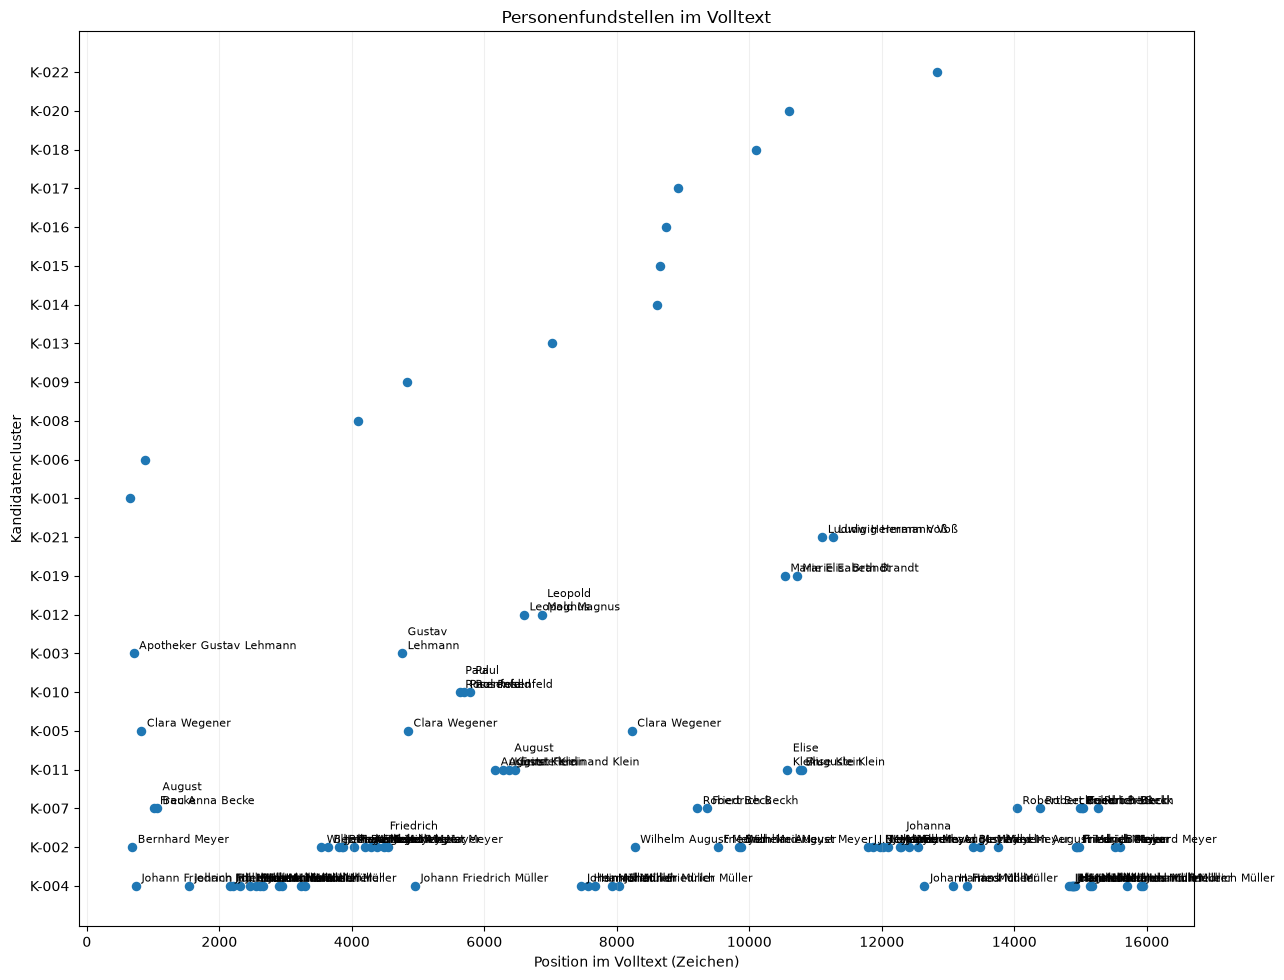

In [13]:
import matplotlib.pyplot as plt

plot_df = candidates_df.copy()

cluster_order = (
    plot_df["Kandidat"]
    .value_counts()
    .index
    .tolist()
)

clusters = {
    candidate: i
    for i, candidate in enumerate(cluster_order)
}

plot_df["y"] = plot_df["Kandidat"].map(clusters)

fig, ax = plt.subplots(figsize=(13, max(5, len(clusters) * 0.45)))

ax.scatter(
    plot_df["Zeichen_Start"],
    plot_df["y"],
    s=34,
)

# Beschriftung nur bei Clustern mit mehreren Fundstellen,
# sonst wird die Grafik bei größeren Texten sofort unlesbar.
cluster_sizes = plot_df["Kandidat"].value_counts()

for _, row in plot_df.iterrows():
    if cluster_sizes[row["Kandidat"]] < 2:
        continue

    ax.annotate(
        row["Name_im_Text"],
        (row["Zeichen_Start"], row["y"]),
        xytext=(4, 3),
        textcoords="offset points",
        fontsize=8,
    )

ax.set_yticks(list(clusters.values()))
ax.set_yticklabels(list(clusters.keys()))
ax.set_xlabel("Position im Volltext (Zeichen)")
ax.set_ylabel("Kandidatencluster")
ax.set_title("Personenfundstellen im Volltext")
ax.grid(axis="x", alpha=0.2)

plt.tight_layout()
plt.show()


## 10. Kandidatencluster mit einem lokalen LLM bewerten

Bis hierher war die Gruppierung rein algorithmisch:

**Namensähnlichkeit / Phonetik → Kandidatencluster**

Jetzt verwenden wir ein lokales Sprachmodell für eine **andere Aufgabe**:

> Stimmen die Kontexte innerhalb eines Clusters dafür, dass bestimmte Fundstellen
> dieselbe Person meinen?

Das Modell darf ausschließlich die angegebenen Belegtexte verwenden.

Es bekommt keine Aufgabe, eine historische Identität „herauszufinden“, sondern soll:

1. wahrscheinlich identische Fundstellen gruppieren,
2. klare Gegenbelege benennen,
3. unklare Fundstellen ausdrücklich offenlassen,
4. seine Entscheidung mit konkreter Evidenz aus den Belegen begründen.


In [15]:
import os
from getpass import getpass
from openai import OpenAI

BASE_URL = os.environ.get(
    "TELOTA_AI_BASE_URL",
    "https://telota-ai-api.bbaw.de/api",
)

LLM_MODEL = "gpt-oss:20b"

api_key = os.environ.get("TELOTA_AI_API_KEY")
if not api_key:
    api_key = getpass("TELOTA AI API key: ")

client = OpenAI(
    base_url=BASE_URL,
    api_key=api_key,
)

print("Endpoint:", BASE_URL)
print("Modell:", LLM_MODEL)


TELOTA AI API key:  ········


Endpoint: https://telota-ai-api.bbaw.de/api
Modell: gpt-oss:20b


### Welche Cluster schicken wir ans LLM?

Für eine Demo müssen nicht fünfzig triviale Einzelcluster durch das Modell.

Wir bewerten nur Cluster mit mindestens zwei Fundstellen. Standardmäßig werden die
größten Cluster zuerst verarbeitet.

Für einen Vortrag kann `TARGET_CLUSTERS` z. B. auf den Müller-Cluster begrenzt werden:

```python
TARGET_CLUSTERS = ["K-003"]
```

Eine leere Liste bedeutet: automatisch die größten problematischen Cluster wählen.


In [16]:
MAX_LLM_CLUSTERS = 8
TARGET_CLUSTERS = []  # z. B. ["K-003"]; leer = automatisch


cluster_sizes = (
    candidates_df
    .groupby("Kandidat")
    .size()
    .sort_values(ascending=False)
)

eligible_clusters = cluster_sizes[
    cluster_sizes >= 2
].index.tolist()

if TARGET_CLUSTERS:
    llm_clusters = [
        cluster
        for cluster in TARGET_CLUSTERS
        if cluster in eligible_clusters
    ]
else:
    llm_clusters = eligible_clusters[:MAX_LLM_CLUSTERS]

print("LLM-Cluster:", llm_clusters)


LLM-Cluster: ['K-004', 'K-002', 'K-007', 'K-011', 'K-005', 'K-010', 'K-019', 'K-021']


### Mention-IDs vergeben

Das LLM darf **nur vorhandene IDs** zurückgeben.

Dadurch können wir nach dem Call deterministisch prüfen, ob das Modell:

- Fundstellen erfunden hat,
- Fundstellen doppelt verwendet,
- oder Fundstellen einfach verschwinden lässt.


In [17]:
mentions_df = candidates_df.copy()
mentions_df["Mention_ID"] = [
    f"M{i:04d}"
    for i in range(1, len(mentions_df) + 1)
]

display(
    mentions_df[
        [
            "Mention_ID",
            "Kandidat",
            "Name_im_Text",
            "NER_Konfidenz",
            "Kontext",
        ]
    ].head(50)
)


,Mention_ID,Kandidat,Name_im_Text,NER_Konfidenz,Kontext
2,M0001,K-001,Carl Friedrich Becker,0.551378,ch Wilhelm Hartung die erste Sitzung des Jahre...
3,M0002,K-002,Bernhard Meyer,0.423696,des Jahres im Rathaus zu Neustadt an der Havel...
4,M0003,K-003,Apotheker Gustav Lehmann,0.400347,us zu Neustadt an der Havel. Anwesend waren de...
5,M0004,K-004,Johann Friedrich Müller,0.681915,waren der Stadtverordnete Carl Friedrich Becke...
6,M0005,K-005,Clara Wegener,0.642818,"r Apotheker Gustav Lehmann, der Lehrer Johann ..."
7,M0006,K-006,Magistratssekretär Theodor Krüger,0.425878,drich Müller sowie die Vorsteherin der weiblic...
8,M0007,K-007,Frau Anna Becke,0.429503,Krüger bestimmt. Gegenstand der Beratung war z...
9,M0008,K-007,August\nBecke,0.468755,tung war zunächst die Erweiterung der städtisc...
10,M0009,K-004,Johann Friedrich Müller,0.762496,rgelegt worden sei. Die damaligen Akten seien ...
11,M0010,K-004,Joh. Müller,0.753855,en der „Naturgeschichte für Schule und Haus“ a...


In [18]:
def build_cluster_prompt(cluster_id: str, group: pd.DataFrame) -> str:
    mentions = []

    for _, row in group.iterrows():
        mentions.append({
            "id": row["Mention_ID"],
            "name": row["Name_im_Text"],
            "context": row["Kontext"],
        })

    payload = json.dumps(
        mentions,
        ensure_ascii=False,
        indent=2,
    )

    return f"""
Du unterstützt die archivische Disambiguierung eines Personenregisters.

Die folgenden Fundstellen wurden ausschließlich aufgrund von Namensähnlichkeit
algorithmisch zu einem Kandidatencluster zusammengefasst.

Cluster: {cluster_id}

Verwende ausschließlich die angegebenen Belegtexte.
Nutze kein externes Wissen und ergänze keine biographischen Fakten.

Aufgabe:
1. Gruppiere Fundstellen, die wahrscheinlich dieselbe Person meinen.
2. Trenne Fundstellen, für die der Kontext gegen Identität spricht.
3. Markiere Fundstellen als unsicher, wenn die Quelle keine Entscheidung erlaubt.
4. Begründe jede Gruppe ausschließlich mit konkreten Indizien aus den Belegtexten.

Achte insbesondere auf:
- Beruf oder Funktion
- Ort
- Institution
- Verwandtschaftsbeziehungen
- zeitliche Konsistenz
- explizite Gleichsetzungen
- explizite Ausschlüsse wie "nicht zu verwechseln"

Jede Mention-ID muss entweder genau einmal in "groups" oder genau einmal
in "uncertain" vorkommen.

Antworte ausschließlich als valides JSON:

{{
  "groups": [
    {{
      "group_id": "G1",
      "mentions": ["M0001", "M0002"],
      "confidence": 0.0,
      "evidence": ["kurzer Quellenbeleg", "weiterer Quellenbeleg"]
    }}
  ],
  "uncertain": ["M0003"],
  "notes": "optionale kurze Gesamtbemerkung"
}}

"confidence" ist nur deine eigene Einschätzung zwischen 0 und 1.

Fundstellen:
{payload}
""".strip()


def parse_llm_json(text: str) -> dict:
    value = (text or "").strip()

    value = re.sub(
        r"^```(?:json)?\\s*",
        "",
        value,
        flags=re.I,
    )
    value = re.sub(r"\\s*```$", "", value)

    return json.loads(value)


### LLM-Antwort validieren

Ein syntaktisch korrektes JSON reicht nicht.

Wir prüfen anschließend ohne weiteres Modell:

- nur bekannte Mention-IDs?
- jede Mention genau einmal?
- keine Dubletten?
- keine Fundstelle vergessen?
- sinnvolle Gruppenstruktur?


In [19]:
def validate_cluster_assessment(
    assessment: dict,
    valid_ids: set[str],
) -> list[str]:
    issues = []

    if not isinstance(assessment, dict):
        return ["Antwort ist kein JSON-Objekt."]

    groups = assessment.get("groups", [])
    uncertain = assessment.get("uncertain", [])

    if not isinstance(groups, list):
        issues.append("'groups' ist keine Liste.")
        groups = []

    if not isinstance(uncertain, list):
        issues.append("'uncertain' ist keine Liste.")
        uncertain = []

    used = []

    for index, group in enumerate(groups, start=1):
        if not isinstance(group, dict):
            issues.append(f"Gruppe {index} ist kein Objekt.")
            continue

        mention_ids = group.get("mentions", [])

        if not isinstance(mention_ids, list):
            issues.append(
                f"Gruppe {index}: 'mentions' ist keine Liste."
            )
            continue

        if not mention_ids:
            issues.append(f"Gruppe {index} ist leer.")

        used.extend(mention_ids)

    used.extend(uncertain)

    unknown = sorted(set(used) - valid_ids)
    if unknown:
        issues.append(
            "Erfundene/unbekannte Mention-IDs: "
            + ", ".join(unknown)
        )

    duplicates = sorted({
        mention_id
        for mention_id in used
        if used.count(mention_id) > 1
    })
    if duplicates:
        issues.append(
            "Mention-IDs mehrfach verwendet: "
            + ", ".join(duplicates)
        )

    missing = sorted(valid_ids - set(used))
    if missing:
        issues.append(
            "Mention-IDs fehlen: "
            + ", ".join(missing)
        )

    return issues


In [20]:
cluster_assessments = {}

for cluster_id in llm_clusters:
    group = mentions_df[
        mentions_df["Kandidat"] == cluster_id
    ].copy()

    valid_ids = set(group["Mention_ID"])

    prompt = build_cluster_prompt(
        cluster_id,
        group,
    )

    response = client.chat.completions.create(
        model=LLM_MODEL,
        temperature=0,
        messages=[
            {
                "role": "system",
                "content": (
                    "Du arbeitest quellenkritisch. "
                    "Du darfst ausschließlich die vorgelegten "
                    "Belegtexte verwenden."
                ),
            },
            {
                "role": "user",
                "content": prompt,
            },
        ],
    )

    raw = response.choices[0].message.content

    try:
        assessment = parse_llm_json(raw)
        issues = validate_cluster_assessment(
            assessment,
            valid_ids,
        )
    except Exception as exc:
        assessment = None
        issues = [f"Antwort konnte nicht geparst werden: {exc}"]

    cluster_assessments[cluster_id] = {
        "assessment": assessment,
        "issues": issues,
        "raw": raw,
    }

    status = "OK" if not issues else "PRÜFEN"
    print(
        f"{cluster_id}: {status} "
        f"({len(group)} Fundstellen)"
    )
    for issue in issues:
        print("  •", issue)


K-004: PRÜFEN (34 Fundstellen)
  • Antwort konnte nicht geparst werden: Expecting value: line 1 column 1 (char 0)
K-002: OK (33 Fundstellen)
K-007: OK (10 Fundstellen)
K-011: OK (7 Fundstellen)
K-005: OK (3 Fundstellen)
K-010: OK (3 Fundstellen)
K-019: OK (2 Fundstellen)
K-021: OK (2 Fundstellen)


## 11. LLM-vorgeschlagene Untergruppen visualisieren

Jetzt wird sichtbar, was der zweite Schritt tatsächlich leistet:

**Kandidatencluster → quellenbasierte Untergruppen**

Die LLM-Gruppen sind weiterhin **Vorschläge**. Bei einer ungültigen Modellantwort wird
nichts stillschweigend übernommen; der Cluster bleibt zur Prüfung markiert.


In [21]:
def show_llm_cluster_review(
    cluster_id: str,
    mentions_df: pd.DataFrame,
    result: dict,
):
    group = mentions_df[
        mentions_df["Kandidat"] == cluster_id
    ].copy()

    lookup = (
        group
        .set_index("Mention_ID")
        .to_dict("index")
    )

    assessment = result.get("assessment")
    issues = result.get("issues", [])

    if assessment is None:
        display(Markdown(
            f"### {cluster_id} · ⚠️ keine auswertbare LLM-Antwort"
        ))
        for issue in issues:
            print("•", issue)
        return

    issue_html = ""

    if issues:
        issue_html = (
            "<div style='border:1px solid #b77;"
            "padding:10px;border-radius:8px;"
            "margin-bottom:12px'>"
            "<strong>⚠️ Validierungsprobleme</strong><ul>"
            + "".join(
                f"<li>{html.escape(str(issue))}</li>"
                for issue in issues
            )
            + "</ul></div>"
        )

    group_blocks = []

    for proposed_group in assessment.get("groups", []):
        mention_ids = proposed_group.get("mentions", [])
        confidence = proposed_group.get("confidence")
        evidence = proposed_group.get("evidence", [])

        mention_html = []

        for mention_id in mention_ids:
            row = lookup.get(mention_id)

            if not row:
                continue

            mention_html.append(
                f"""
                <div style="
                    border-left:3px solid #888;
                    padding-left:8px;
                    margin:8px 0;
                ">
                    <strong>
                        {html.escape(str(row["Name_im_Text"]))}
                    </strong>
                    <small>
                        · {html.escape(str(mention_id))}
                    </small>
                    <div style="
                        margin-top:3px;
                        font-size:0.9em;
                    ">
                        {html.escape(str(row["Kontext"]))}
                    </div>
                </div>
                """
            )

        evidence_html = "".join(
            f"<li>{html.escape(str(item))}</li>"
            for item in evidence
        )

        conf_text = (
            f"{float(confidence):.2f}"
            if isinstance(confidence, (int, float))
            else "–"
        )

        group_blocks.append(
            f"""
            <div style="
                border:1px solid #ccc;
                border-radius:8px;
                padding:10px;
                margin:10px 0;
            ">
                <div style="
                    display:flex;
                    justify-content:space-between;
                    gap:12px;
                ">
                    <strong>
                        {html.escape(str(proposed_group.get("group_id", "Gruppe")))}
                    </strong>
                    <span>
                        LLM confidence {conf_text}
                    </span>
                </div>

                {''.join(mention_html)}

                <details>
                    <summary>LLM-Evidenz</summary>
                    <ul>{evidence_html}</ul>
                </details>
            </div>
            """
        )

    uncertain_ids = assessment.get("uncertain", [])

    uncertain_html = ""

    if uncertain_ids:
        items = []

        for mention_id in uncertain_ids:
            row = lookup.get(mention_id)
            if not row:
                continue

            items.append(
                f"""
                <li>
                    <strong>
                        {html.escape(str(row["Name_im_Text"]))}
                    </strong>
                    ({html.escape(str(mention_id))})
                </li>
                """
            )

        uncertain_html = (
            "<div style='border:1px dashed #999;"
            "padding:10px;border-radius:8px;"
            "margin-top:12px'>"
            "<strong>Ungeklärt</strong><ul>"
            + "".join(items)
            + "</ul></div>"
        )

    display(HTML(
        f"""
        <div style="margin:18px 0 28px 0">
            <h3>{html.escape(str(cluster_id))}</h3>
            {issue_html}
            {''.join(group_blocks)}
            {uncertain_html}
        </div>
        """
    ))


for cluster_id in llm_clusters:
    show_llm_cluster_review(
        cluster_id,
        mentions_df,
        cluster_assessments[cluster_id],
    )


### K-004 · ⚠️ keine auswertbare LLM-Antwort

• Antwort konnte nicht geparst werden: Expecting value: line 1 column 1 (char 0)


## 12. LLM-Bewertung als Prüfdatensatz exportieren

Wir übernehmen keine vorgeschlagene Identität automatisch.

Stattdessen ergänzen wir die ursprünglichen Fundstellen um:

- vorgeschlagene LLM-Untergruppe,
- LLM-Selbsteinschätzung,
- LLM-Evidenz,
- Validierungsstatus,
- leere Spalte für die archivfachliche Entscheidung.

Damit bleibt der Modellvorschlag nachvollziehbar und reversibel.


In [22]:
review_rows = []

for cluster_id, result in cluster_assessments.items():
    assessment = result.get("assessment")
    issues = result.get("issues", [])

    if assessment is None:
        continue

    for group in assessment.get("groups", []):
        evidence = " | ".join(
            str(item)
            for item in group.get("evidence", [])
        )

        for mention_id in group.get("mentions", []):
            review_rows.append({
                "Kandidat": cluster_id,
                "Mention_ID": mention_id,
                "LLM_Untergruppe": group.get("group_id"),
                "LLM_Confidence": group.get("confidence"),
                "LLM_Evidenz": evidence,
                "LLM_Status": (
                    "OK"
                    if not issues
                    else "PRÜFEN"
                ),
            })

    for mention_id in assessment.get("uncertain", []):
        review_rows.append({
            "Kandidat": cluster_id,
            "Mention_ID": mention_id,
            "LLM_Untergruppe": "uncertain",
            "LLM_Confidence": None,
            "LLM_Evidenz": assessment.get("notes", ""),
            "LLM_Status": (
                "OK"
                if not issues
                else "PRÜFEN"
            ),
        })


llm_review_df = pd.DataFrame(
    review_rows,
    columns=[
        "Kandidat",
        "Mention_ID",
        "LLM_Untergruppe",
        "LLM_Confidence",
        "LLM_Evidenz",
        "LLM_Status",
    ],
)

final_review_df = mentions_df.merge(
    llm_review_df,
    on=["Kandidat", "Mention_ID"],
    how="left",
)

final_review_df["Archiventscheidung"] = ""

LLM_REVIEW_CSV = (
    OUTPUT_DIR
    / "03_kandidatenindex_llm_review.csv"
)

final_review_df.to_csv(
    LLM_REVIEW_CSV,
    index=False,
    sep=";",
    encoding="utf-8-sig",
)

display(final_review_df.head(100))
print(
    f"LLM-Prüfdatensatz geschrieben: "
    f"{LLM_REVIEW_CSV.resolve()}"
)


,Kandidat,Name_im_Text,Normalisierte_Form,Nachname,Phonetischer_Schluessel,NER_Konfidenz,Zeichen_Start,Zeichen_Ende,Kontext,Archiventscheidung,Mention_ID,LLM_Untergruppe,LLM_Confidence,LLM_Evidenz,LLM_Status
0,K-001,Carl Friedrich Becker,carl friedrich becker,becker,147,0.551378,649,670,ch Wilhelm Hartung die erste Sitzung des Jahre...,,M0001,NaN,NaN,NaN,NaN
1,K-002,Bernhard Meyer,bernhard meyer,meyer,67,0.423696,685,699,des Jahres im Rathaus zu Neustadt an der Havel...,,M0002,G1,0.97,"""der Kaufmann Bernhard Meyer"" | ""Bernhard Meye...",OK
2,K-003,Apotheker Gustav Lehmann,apotheker gustav lehmann,lehmann,566,0.400347,705,729,us zu Neustadt an der Havel. Anwesend waren de...,,M0003,NaN,NaN,NaN,NaN
3,K-004,Johann Friedrich Müller,johann friedrich müller,müller,657,0.681915,742,765,waren der Stadtverordnete Carl Friedrich Becke...,,M0004,NaN,NaN,NaN,NaN
4,K-005,Clara Wegener,clara wegener,wegener,3467,0.642818,823,836,"r Apotheker Gustav Lehmann, der Lehrer Johann ...",,M0005,G1,0.95,M0005 und M0035 beschreiben Clara Wegener als ...,OK
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,K-004,Hannes Müller,hannes müller,müller,657,0.763549,14920,14933,fanden sich nebeneinander: Johann Friedrich Mü...,,M0096,NaN,NaN,NaN,NaN
96,K-002,Friedrich Meier,friedrich meier,meier,67,0.709425,14936,14951,"eneinander: Johann Friedrich Müller, Joh. Müll...",,M0097,G4,0.85,"""Friedrich Meier"" | ""Friedrich Meyer"" | ""Fried...",OK
97,K-002,Friedrich Meyer,friedrich meyer,meyer,67,0.720392,14953,14968,"nn Friedrich Müller, Joh. Müller, J. F. Müller...",,M0098,G4,0.85,"""Friedrich Meier"" | ""Friedrich Meyer"" | ""Fried...",OK
98,K-002,Friedrich Mayer,friedrich mayer,mayer,67,0.474323,14970,14985,"er, Joh. Müller, J. F. Müller, J. Müller; Hann...",,M0099,G4,0.85,"""Friedrich Meier"" | ""Friedrich Meyer"" | ""Fried...",OK


LLM-Prüfdatensatz geschrieben: /home/jovyan/work/ki_in_kleinen_archiven/output/03_kandidatenindex_llm_review.csv


## Was zeigt die zweistufige Methode?

```text
Volltext
   ↓
GLiNER
   ↓
Personenfundstellen
   ↓
phonetisches / unscharfes Matching
   ↓
großzügige Kandidatencluster
   ↓
lokales LLM vergleicht die Belegkontexte
   ↓
vorgeschlagene Untergruppen + Evidenz
   ↓
deterministische Validierung des LLM-Outputs
   ↓
archivfachliche Entscheidung
```

Der erste Algorithmus fragt:

> **Welche Namen könnten zusammengehören?**

Das lokale LLM fragt:

> **Welche dieser Fundstellen sprechen aufgrund der Quelle tatsächlich für dieselbe Person?**

Und die letzte Entscheidung bleibt beim Archiv.


## 13. Basis-Kandidatenindex als CSV exportieren

Der Kandidatenindex wird als einfache UTF-8-CSV gespeichert.

- **eine Zeile pro Personenfundstelle**
- Semikolon als Trennzeichen
- UTF-8 mit BOM (`utf-8-sig`), damit auch Excel unter Windows die Umlaute sauber öffnet

Die CSV bleibt ein **Prüfbestand**. Die eigentliche Identitätsentscheidung ist die
leere Spalte `Archiventscheidung`.


In [23]:
candidates_df.to_csv(
    CSV_PATH,
    index=False,
    sep=";",
    encoding="utf-8-sig",
)

print(f"CSV geschrieben: {CSV_PATH}")
print(f"Personenfundstellen: {len(candidates_df):,}")
print(
    "Kandidatencluster:",
    candidates_df["Kandidat"].nunique() if not candidates_df.empty else 0,
)


CSV geschrieben: output/03_kandidatenindex.csv
Personenfundstellen: 110
Kandidatencluster: 22


## Ergebnis

```text
Volltext
  ↓
überlappende GLiNER-Fenster
  ↓
Personenfundstellen + Dokumentkoordinaten
  ↓
Kontext aus dem Gesamttext
  ↓
Normalisierung + phonetisches Matching
  ↓
Kandidatenindex
  ↓
CSV
  ↓
archivfachliche Disambiguierung
```

Die Maschine kann gut sagen, **wo Personen erwähnt werden** und
**welche Schreibvarianten zusammengehören könnten**.

> Ob zwei „Hanns Müller“ dieselbe Person sind, entscheidet das Archiv.
